In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time

main_folder_path = '/Users/glavezzi/Desktop/pyssem/pyssem'
sys.path.append(main_folder_path) 

Assumptions:

- Why lines 369 and 377? They are to change Su to S and D to N; but I commented out in this case I don’t think we need them correct?
    - Those lines are just left over from the comparison between MC and SSEM. MC only made derelicts after the simulation started and didn't account for D in the initial population. I had to make SSEM the same. You shouldn't need to set a D species in the JSON, it should be made automatically in the PMD code.

- Species mapping question: Do you definitely need the SU mapping? Are they being differentiated by the Polimi? Because it will essentially just mean that you can change the collision probabilities between species. But if they are going to all be 0 between active satellites, you can just keep all satellites as S.
    - Basically, PMD = 0.9, alpha and alpha_active = 0, delta_t = 5. So yes, both S and Su have the same parameters. Would the slotting and slotting effectiveness change anything in S wrt Su? If not, I might do as you say, so everything is S, so that it is easier to compare w/ MC too.
        - Then yes, I would just keep the S class (at least to start with). I think if they haven't specified the differences in the collision avoidance between different satellite types, then alpha and alpha_active should remain the same for all the satellites. As I assume that they will be modelling it like this.

- Instead does it make sense to re-assign the species_classes Su (and S) to D if the launch date provided is before a certain year in the csv? Or I just keep as active satellites even if the launch date is in the past? This was another doubt I had.
    - I am not entirely sure what you mean here -> "Su (and S) to D if the launch date provided is before a certain year in the csv?". For satellites that were launched before the start date, they will all start their deorbiting as soon as the simulation starts. There's no way to differentiate the PMD date.. Is this what you mean?

- And, another doubt, are we able to simulate this “performing manoeuvres that allow re-entries in maximum 25 years. So, after the end of lifetime (set to 5 years) the objects are let decay without further action.” Like does that mean to set the delta_t to 5 or 25? Because if I set it to 5, then after 5 years the PMD will begin, but we don’t have a max time for it, if not wrong.
    - Regarding PMD, it seems that it is the delta_t would be 25 years.

- This should automatically work. The constant launch rate was actually a matter of re-generating the launch dates in the CSV to make a certain amount launched each year. Yes exactly. The launch rate was only made constant to ensure that the SSEM and MC matches perfectly, this is not strictly necessary! This was done in the early days of the comparisons between the models. 

# Workshop data (.csv) preparation for ingestion in SSEM

In [2]:
filename = main_folder_path + '/utils/launch/data/ref_scen_SEP2C_mine.csv'  # Replace with your actual file path
df0 = pd.read_csv(filename)
print("Columns found in file:", df0.columns.tolist())

filename = main_folder_path + '/utils/launch/data/ref_scen_SEP2C.csv'  # Replace with your actual file path
df = pd.read_csv(filename)
print("Columns found in file:", df.columns.tolist())

filename = main_folder_path + '/utils/launch/data/ex1_intact_objs_nfl.csv'  # Replace with your actual file path
df1 = pd.read_csv(filename)
# Prepare the mapping for 'object type' to 'species_class'
mapping = {
    'Starlink': 'S', 
    'OneWeb': 'S', 
    'Kuiper': 'S', 
    'Iridium': 'S',
    'Qianfan': 'S', 
    'Jilin': 'S',
    'Globalstar': 'S', 
    'OrbComm': 'S',
    'Meteor': 'S',  
    'Astrocast': 'S', 
    'Payload': 'S', # or Su (see assumptions in cell above)
    'Yinhe': 'S', # or Su
    'Lynk': 'S', # or Su
    'Xingshidai': 'S', # or Su
    'Starshield': 'S', # or Su
    'Swarm': 'S', # or Su
    'Strela': 'S', # or Su
    'Flock': 'S', # or Sns
    'Rocket Body': 'B',
    'MRO': 'N'
}
# Apply the mapping to create the new column
df1['species_class'] = df1['object type'].map(mapping)
print("Columns found in file:", df1.columns.tolist())
# Check for any unmapped types (will show as NaN)
if df1['species_class'].isnull().any():
    print("Warning: Some object types were not mapped!")
    print(df1[df1['species_class'].isnull()]['object type'].unique())
else:
    print("All object types were successfully mapped.")

# # NOT NEEDED based on assumptions in cell above
# # Re-assign 'Su' to 'D' if launched before 2020
# # This targets things like older 'Payload', 'Strela', or 'Meteor' objects
# df1.loc[
#     (df1['species_class'] == 'Su') & 
#     (df1['status [-]'] < 2020), 
#     'species_class'
# ] = 'D'

filename = main_folder_path + '/utils/launch/data/ex1_debris_data.csv'  # Replace with your actual file path
df2 = pd.read_csv(filename)
df2['object type'] = 'Debris'
df2['date [-]'] = '2025-12-31' # 2025-12-31 61040 ; 2026-01-01 61041
df2['MJD [-]'] = 61040
df2['species_class'] = 'N'
df2 = df2[df1.columns]
print("Columns found in file:", df2.columns.tolist())

print("\n--- Species class counts in df ---")
print(df['species_class'].value_counts())

print("\n--- Species class counts in df1 ---")
print(df1['species_class'].value_counts())

print("\n--- Species class counts in df2 ---")
print(df2['species_class'].value_counts())


Columns found in file: ['adept_id', 'epoch_start', 'sma', 'ecc', 'inc', 'raan', 'aop', 'ma', 'epoch_end', 'obj_type', 'disp_option', 'stationkeeping', 'area', 'mass', 'size', 'weight']
Columns found in file: ['obj_id', 'phase_desc', 'phase', 'par_id', 'operating_agency', 'const_name', 'const_shell_id', 'mass', 'area', 'diam_lcola', 'diam_tumbl', 'diam_char', 'obj_type', 'length', 'width', 'depth', 'active', 'maneuverable', 'stkp_flg', 'stkp_box_r', 'stkp_box_i', 'stkp_box_c', 'disp_type', 'c2r', 'pc_thresh', 'pc_goal', 'man_commit', 'man_max_dv', 'man_dv_i_flg', 'year_start', 'month_start', 'day_start', 'hour_start', 'minute_start', 'second_start', 'mjd_start', 'year_final', 'month_final', 'day_final', 'hour_final', 'minute_final', 'second_final', 'mjd_final', 'year_epoch', 'month_epoch', 'day_epoch', 'hour_epoch', 'minute_epoch', 'second_epoch', 'mjd_epoch', 'sma', 'ecc', 'inc', 'raan', 'aop', 'ma', 'eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy', 'eci_vz', 'obj_id_str', 'species_class'

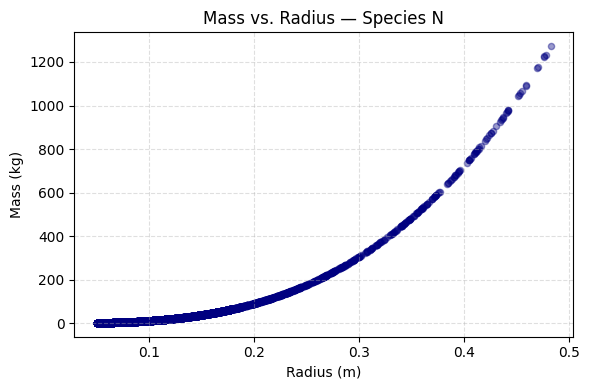

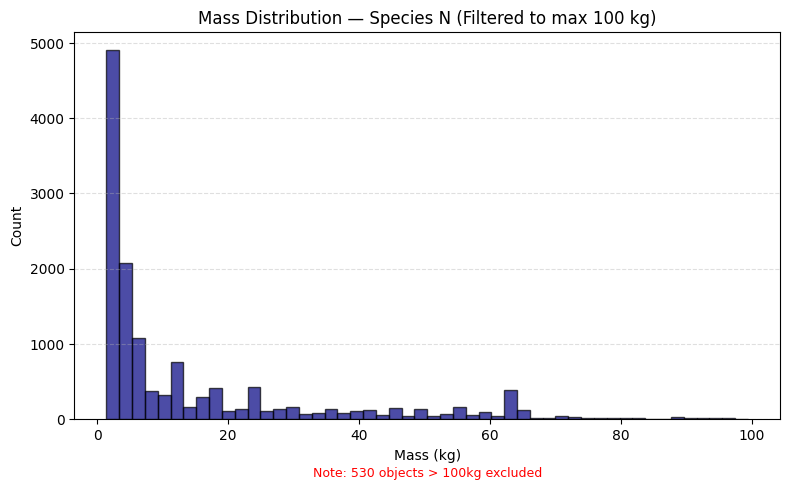

In [ ]:
big_mass = 10000000
assigned_df = df2
mass_radius_df = assigned_df[['species_class','mass [kg]','area [m^2]']].dropna()
mass_radius_df['radius'] = np.sqrt(assigned_df['area [m^2]'] / np.pi)

for sp, group in mass_radius_df.groupby('species_class'):
    plt.figure(figsize=(6,4))
    
    big_mass_points = group['mass [kg]'] > big_mass
    
    # Plot normal points
    plt.scatter(
        group.loc[~big_mass_points, 'radius'],
        group.loc[~big_mass_points, 'mass [kg]'],
        s=20, alpha=0.4, color = 'navy', label='not outlier'
    )

    plt.scatter(
        group.loc[big_mass_points, 'radius'],
        group.loc[big_mass_points, 'mass [kg]'],
        s=20, alpha=0.9, color='deeppink', edgecolor='red', label='outlier'
    )
    
    plt.title(f"Mass vs. Radius — Species {sp}")
    plt.xlabel("Radius (m)")
    plt.ylabel("Mass (kg)")
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()


# --- CONFIGURATION ---
max_mass_to_show = 100  # <--- SET YOUR MAX MASS LIMIT HERE (in kg)
bins_count = 50           # Number of bars in the histogram
# ---------------------

assigned_df = df2
# Clean data: select columns and remove rows with missing masses
hist_df = assigned_df[['species_class', 'mass [kg]']].dropna()

for sp, group in hist_df.groupby('species_class'):
    # Filter the data based on your chosen max mass
    filtered_data = group[group['mass [kg]'] <= max_mass_to_show]['mass [kg]']
    
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        filtered_data, 
        bins=bins_count, 
        color='navy', 
        alpha=0.7, 
        edgecolor='black'
    )
    
    plt.title(f"Mass Distribution — Species {sp} (Filtered to max {max_mass_to_show} kg)")
    plt.xlabel("Mass (kg)")
    plt.ylabel("Count")
    
    # Optional: show the count of objects that were filtered out
    total_in_species = len(group)
    shown_in_plot = len(filtered_data)
    if total_in_species > shown_in_plot:
        plt.annotate(f"Note: {total_in_species - shown_in_plot} objects > {max_mass_to_show}kg excluded", 
                     xy=(0.5, -0.15), xycoords='axes fraction', ha='center', fontsize=9, color='red')

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    

In [3]:
df12 = pd.concat([df1, df2], ignore_index=True)
print("\n--- Species class counts in df12 ---")
print(df12['species_class'].value_counts())


--- Species class counts in df12 ---
S    14499
N    14459
B     1002
Name: species_class, dtype: int64


In [4]:
filename = main_folder_path + '/utils/launch/data/ex1_intact_objs_baseline.csv'  # Replace with your actual file path
df3 = pd.read_csv(filename)
print("\n--- Species class counts in df3 ---")
print("Columns found in file:", df3.columns.tolist())

unique_values1 = df1['object type'].unique()
print(unique_values1)
unique_values3 = df3['object type'].unique()
print(unique_values3)

# Prepare the mapping for 'object type' to 'species_class'
mapping = {
    'Starlink': 'S', 
    'OneWeb': 'S', 
    'Kuiper': 'S', 
    'Iridium': 'S',
    'Qianfan': 'S', 
    'Jilin': 'S',
    'Globalstar': 'S', 
    'OrbComm': 'S',
    'Meteor': 'S',  
    'Astrocast': 'S',
    'Guowang': 'S', 
    'Payload': 'S', # or Su (see assumptions in cell above)
    'Yinhe': 'S', # or Su 
    'Lynk': 'S', # or Su 
    'Xingshidai': 'S', # or Su 
    'Starshield': 'S', # or Su 
    'Swarm': 'S', # or Su 
    'Strela': 'S', # or Su 
    'Flock': 'S', # or Sns 
    'Rocket Body': 'B',
    'MRO': 'N'
}
# Apply the mapping to create the new column
df3['species_class'] = df3['object type'].map(mapping)
print("Columns found in file:", df3.columns.tolist())
# Check for any unmapped types (will show as NaN)
if df3['species_class'].isnull().any():
    print("Warning: Some object types were not mapped!")
    print(df3[df3['species_class'].isnull()]['object type'].unique())
else:
    print("All object types were successfully mapped.")

# # NOT NEEDED based on assumptions in cell above
# # Re-assign 'Su' to 'D' if launched before 2020
# # This targets things like older 'Payload', 'Strela', or 'Meteor' objects
# df3.loc[
#     (df3['species_class'] == 'Su') & 
#     (df3['status [-]'] < 2020), 
#     'species_class'
# ] = 'D'


--- Species class counts in df3 ---
Columns found in file: ['object type', 'sma [m]', 'ecc [-]', 'inc [deg]', 'area [m^2]', 'mass [kg]', 'status [-]', 'RAAN [deg]', 'AoP [deg]', 'M [deg]', 'date [-]', 'MJD [-]']
['Payload' 'OrbComm' 'Globalstar' 'Swarm' 'Strela' 'Meteor' 'Jilin'
 'Iridium' 'Astrocast' 'OneWeb' 'Starlink' 'Yinhe' 'Lynk' 'Flock'
 'Rocket Body' 'Xingshidai' 'Qianfan' 'Starshield' 'Kuiper' 'MRO']
['Payload' 'OrbComm' 'Globalstar' 'Swarm' 'Strela' 'Meteor' 'Jilin'
 'Iridium' 'Astrocast' 'OneWeb' 'Starlink' 'Yinhe' 'Lynk' 'Flock'
 'Rocket Body' 'Xingshidai' 'Qianfan' 'Starshield' 'Kuiper' 'MRO'
 'Guowang']
Columns found in file: ['object type', 'sma [m]', 'ecc [-]', 'inc [deg]', 'area [m^2]', 'mass [kg]', 'status [-]', 'RAAN [deg]', 'AoP [deg]', 'M [deg]', 'date [-]', 'MJD [-]', 'species_class']
All object types were successfully mapped.


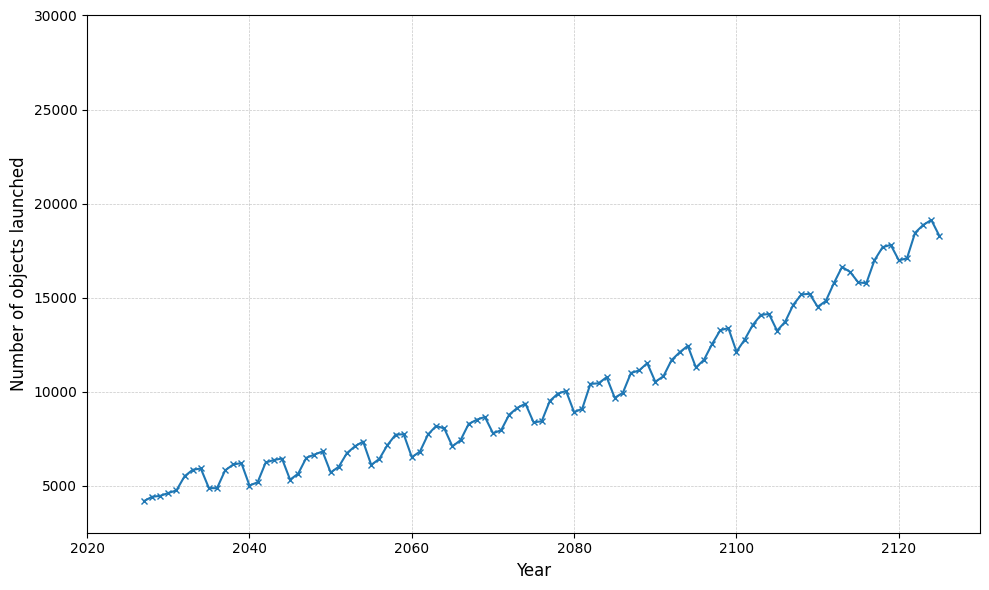

In [125]:
# Filter for future traffic only 
future_df = df3[df3['status [-]'] >= 2027].copy()

# Aggregate: Count number of objects per year
# We group by the 'status [-]' (year) and count the rows
yearly_launches = future_df.groupby('status [-]').size().sort_index()

# Create the plot
plt.figure(figsize=(10, 6), dpi=100)

# Plotting with 'x' markers and a solid line to match the image
plt.plot(yearly_launches.index, yearly_launches.values, 
         marker='x', 
         linestyle='-', 
         color='#1f77b4', # Standard blue
         linewidth=1.5, 
         markersize=5)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of objects launched', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xlim(2020, 2125 + 5)
plt.ylim(2500, 30000)
# Optional: Set y-axis to start at 0 if needed
# plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [5]:
df32 = pd.concat([df3, df2], ignore_index=True)
print("\n--- Species class counts in df32 ---")
print(df32['species_class'].value_counts())


--- Species class counts in df32 ---
S    1012301
N      14459
B       1002
Name: species_class, dtype: int64


In [ ]:
# In scen_properties.py, we have initial_pop_and_launch that calls SEP_traffic_model from launch.py.
# We can create a similar function for the workshop scenario files.

# filename = main_folder_path + '/utils/launch/data/ex1_intact_objs_nfl_new.csv'
# df1.to_csv(filename, index=False)

# filename = main_folder_path + '/utils/launch/data/ex1_intact_objs_nfl_w_debris_new_v2_2025_N.csv'
# df12.to_csv(filename, index=False)

# filename = main_folder_path + '/utils/launch/data/ex1_intact_objs_baseline_new.csv'
# df3.to_csv(filename, index=False)

# filename = main_folder_path + '/utils/launch/data/ex1_intact_objs_baseline_w_debris_new_v2_2025_N.csv'
# df32.to_csv(filename, index=False)

# Statistical analysis to retrieve initial population from dataset

In [13]:
path = main_folder_path + '/utils/launch/data/ex1_intact_objs_nfl_w_debris_new.csv'  # Replace with your actual file path
# path = main_folder_path + '/utils/launch/data/ex1_intact_objs_baseline_w_debris_new.csv'  # Replace with your actual file path
T = pd.read_csv(path)

# Use species_class column directly (should already exist in CSV)
if 'species_class' not in T.columns:
    raise ValueError("Expected 'species_class' column in the input CSV. Please ensure the CSV has been processed with species classification.")

# Filter to include only the species we want: N, Su, Sns, B, S
# valid_species = ['N', 'Su', 'Sns', 'B', 'S']
valid_species = ['N', 'B', 'S']
T = T[T['species_class'].isin(valid_species)]

assigned_df = T

# Rename mass [kg] to mass if it exists (for compatibility)
if 'mass [kg]' in assigned_df.columns and 'mass' not in assigned_df.columns:
    assigned_df.rename(columns={'mass [kg]': 'mass'}, inplace=True)
    assigned_df.rename(columns={'date [-]': 'epoch_start_datetime'}, inplace=True)
    assigned_df['epoch_start_datetime'] = pd.to_datetime(assigned_df['epoch_start_datetime'], errors='coerce')
    assigned_df['year_start'] = assigned_df['epoch_start_datetime'].dt.year

print("Columns found in file:", assigned_df.columns.tolist())

# filter 
# assigned_df = assigned_df[(assigned_df["year_start"] >= 2026) & (assigned_df["year_start"] <= 2040)]
# assigned_df = assigned_df[assigned_df["year_start"] <= 2026]
assigned_df = assigned_df[assigned_df["year_start"] <= 2040]
# assigned_df = assigned_df[assigned_df["year_start"] >= 2026]

print(assigned_df['species_class'].value_counts())

Columns found in file: ['object type', 'sma [m]', 'ecc [-]', 'inc [deg]', 'area [m^2]', 'mass', 'status [-]', 'RAAN [deg]', 'AoP [deg]', 'M [deg]', 'epoch_start_datetime', 'MJD [-]', 'species_class', 'year_start']
S    14499
N    14459
B     1002
Name: species_class, dtype: int64


In [14]:
# These will be outliers we later remove in the statistical analysis for clustering!

big_mass = 2000000
heavy = assigned_df[assigned_df['mass'] > big_mass]

heavy = heavy[heavy['species_class']=="N"] # all others are NA
max_mass = heavy["mass"].max()

if max_mass is np.nan:
    max_mass = big_mass

print(f"Number of objects > {big_mass} kg: {len(heavy)}")
print(heavy['species_class'].value_counts())
print(f"maximum mass: {max_mass}")

heavy

Number of objects > 2000000 kg: 0
Series([], Name: species_class, dtype: int64)
maximum mass: 2000000


,object type,sma [m],ecc [-],inc [deg],area [m^2],mass,status [-],RAAN [deg],AoP [deg],M [deg],epoch_start_datetime,MJD [-],species_class,year_start


In [15]:
remove_outliers = True
assigned_df['species_class'].dropna().unique()

array(['S', 'B', 'N'], dtype=object)

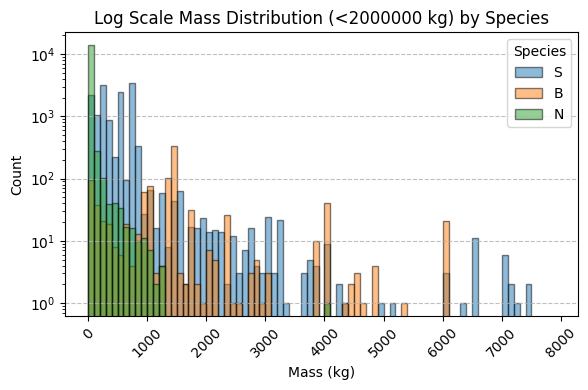

Length of data for S: 14499
Length of data for B: 1002
Length of data for N: 14459


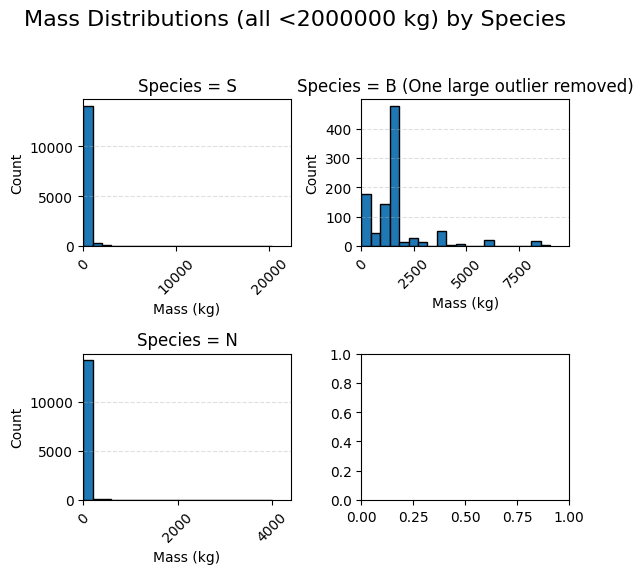

In [16]:
all_species = assigned_df['species_class'].dropna().unique()
bins = np.arange(0, 8000, 100)
plt.figure(figsize=(6,4))

for species in all_species:
    mask = (assigned_df['mass'] < max_mass) & (assigned_df['species_class'] == species)
    subset = assigned_df.loc[mask, 'mass'].dropna()
    # overlay each species, with a bit of transparency
    plt.hist(subset, bins=bins, alpha=0.5, label=species, edgecolor='black')

plt.title(f"Log Scale Mass Distribution (<{max_mass} kg) by Species")
plt.xlabel("Mass (kg)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Species")
plt.yscale('log')

plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()


n = len(all_species)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6, 3*nrows), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sp in zip(axes, all_species):
    data = assigned_df.loc[
        (assigned_df['species_class']==sp) & 
        (assigned_df['mass'] < max_mass),
        'mass'
    ].dropna()
    
    max_data_mass = data.max() if not data.empty else 0
    print(f"Length of data for {sp}: {len(data)}")

    bins_sp = np.arange(0, max_data_mass + 30, max_data_mass / 20)
    ax.hist(data, bins=bins_sp, edgecolor='black')
    
    if sp != "B":
        ax.set_title(f"Species = {sp}")
    else:
        ax.set_title(f"Species = {sp} (One large outlier removed)")

    if max_data_mass > 1:
        ax.set_xlim(0, max_data_mass+(max_data_mass*0.1))  # Add 10% margin to the max mass
    else:
        ax.set_xlim(0, 1)
    
    ax.set_xlabel("Mass (kg)")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # if sp == "Sns":
    #     print(f"All data for {sp}:\n{data.describe()}")
    #     print(list(data))

fig.suptitle(f"Mass Distributions (all <{max_mass} kg) by Species", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


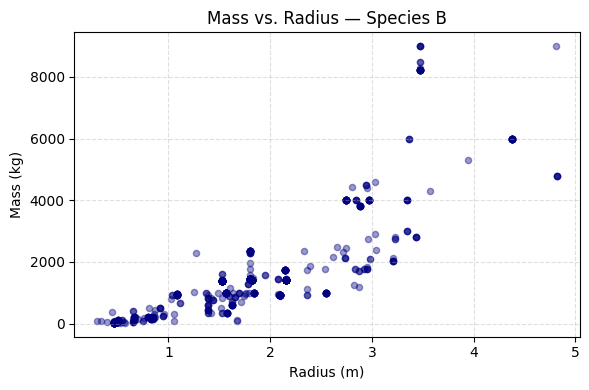

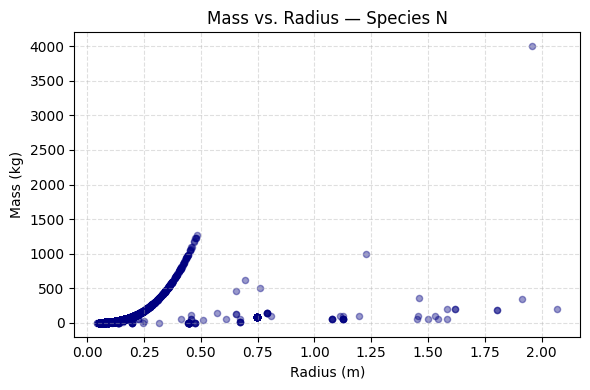

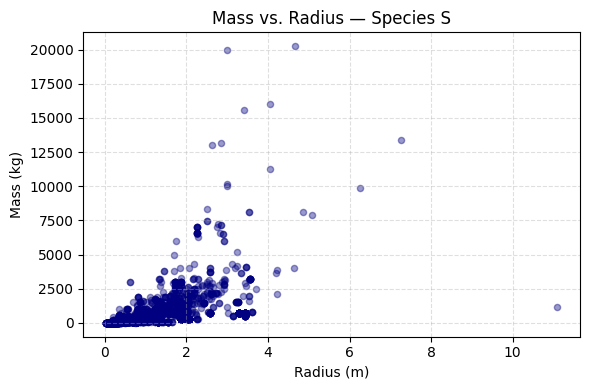

In [17]:
mass_radius_df = assigned_df[['species_class','mass','area [m^2]']].dropna()
mass_radius_df['radius'] = np.sqrt(assigned_df['area [m^2]'] / np.pi)

for sp, group in mass_radius_df.groupby('species_class'):
    plt.figure(figsize=(6,4))

    
    if remove_outliers:
        big_mass_points = group['mass'] > big_mass
    
    # Plot normal points
    plt.scatter(
        group.loc[~big_mass_points, 'radius'],
        group.loc[~big_mass_points, 'mass'],
        s=20, alpha=0.4, color = 'navy', label='not outlier'
    )

    plt.scatter(
        group.loc[big_mass_points, 'radius'],
        group.loc[big_mass_points, 'mass'],
        s=20, alpha=0.9, color='deeppink', edgecolor='red', label='outlier'
    )
    
    plt.title(f"Mass vs. Radius — Species {sp}")
    plt.xlabel("Radius (m)")
    plt.ylabel("Mass (kg)")
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()

## New Statistical Analysis

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids  

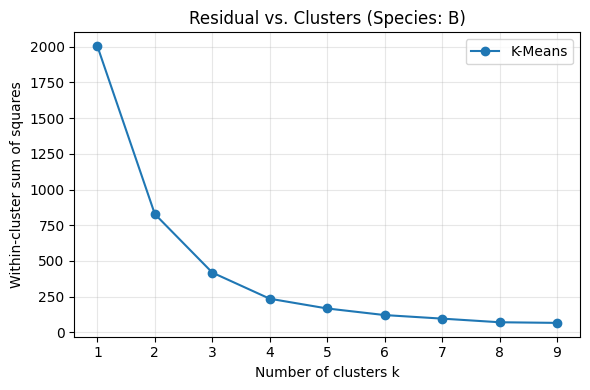

We removed the following N outliers:
Empty DataFrame
Columns: [radius, mass]
Index: []


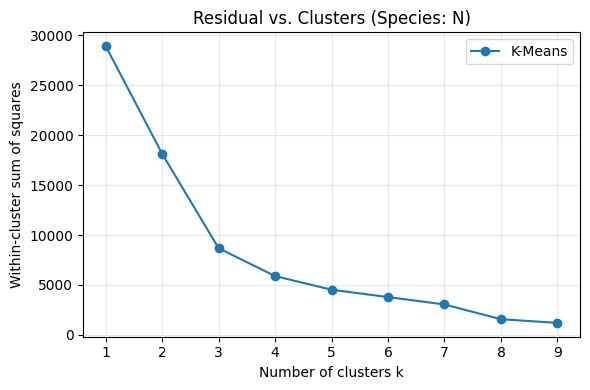

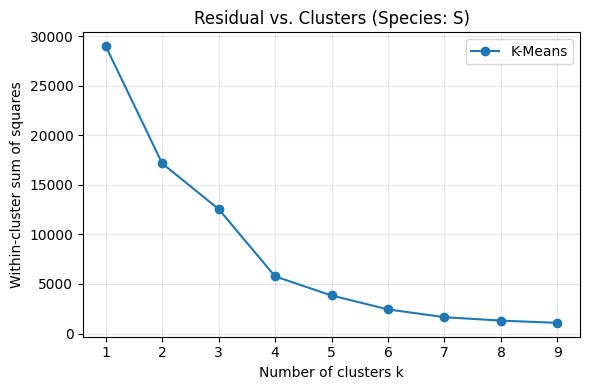

['B', 'N', 'S']

In [19]:
# NOTE: K medoids take much longer to compute. Select the following boolean as needed!
# Set to True to include KMedoids clustering
include_medoids = False

species_groups = mass_radius_df.groupby('species_class')
Xs_by_species = {}
cleaned_groups = {}

for sp, group in species_groups:
    
    # clean up outlier
    if sp == "N":
        S_outliers = group[group['mass'] >= big_mass]
        print("We removed the following N outliers:")
        print(S_outliers[['radius', 'mass']])
        
        group = group[group['mass'] < big_mass]
    cleaned_groups[sp] = group
        
    df = group[['radius', 'mass']].dropna()
    X = df.values
    Xs_by_species[sp] = StandardScaler().fit_transform(X)
    Xs = Xs_by_species[sp] # for use in the loop below
    
    inertia_kmeans  = []
    resid_kmedians  = []
    
    # Computer WCSS (intertia) for k = 1, ..., 8
    ks = range(1,10)
    for k in ks:
        km = KMeans(n_clusters=k, random_state=0).fit(Xs)
        inertia_kmeans.append(km.inertia_)  
        
        # k-medians
        if include_medoids and sp!="N":
            kmn = KMedoids(n_clusters=k, metric='manhattan', init='k-medoids++', random_state=0).fit(Xs)
            # sum of L1 distances to each cluster’s medoid
            # resid = np.sum(kmn.inertia_)  # sklearn_extra uses ‘inertia_’ as sum of distances
            # resid_kmedians.append(resid)
            resid_kmedians.append(kmn.inertia_)
    
    # plot elbow
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertia_kmeans, '-o', label='K-Means')
    if include_medoids and sp!="N":
        plt.plot(ks, resid_kmedians, '-s', label='K-Medoids')
    plt.xticks(ks)
    plt.xlabel('Number of clusters k')
    plt.ylabel('Within-cluster sum of squares')
    plt.title(f'Residual vs. Clusters (Species: {sp})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


species_names = list(Xs_by_species.keys())
species_names


Outcome: 
| Species Class | Recommended Sub-species ($k$) |
| :--- | :--- |
| **B** (Rocket Bodies) | **3** |
| **N** (Debris/MRO) | **4** |
| **S** (Slotted) | **4** |
| **Sns** (Non-station keeping) | **2** |

Outcome (no Sns): 
| Species | Sub-species count ($k$) | Rationale |
| :--- | :--- | :--- |
| **B (Rocket Bodies)** | **3** | Captures the primary variance in size/mass. |
| **N (Debris)** | **3** | Clear mathematical "elbow" point. |
| **S (Active)** | **4** | High diversity in active populations requires more sub-classes. |

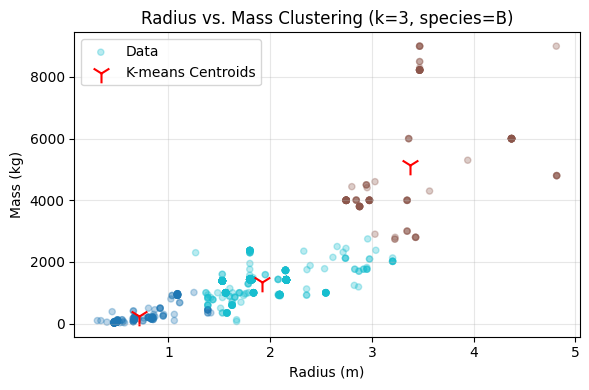

K-means centroid coordinates (radius (m), mass (kg)) for species B (k=3):
  Cluster 1: (0.71042, 252.21146)  n=201
  Cluster 2: (3.37642, 5159.74466)  n=118
  Cluster 3: (1.91642, 1358.40221)  n=683
length of data for species B: 1002


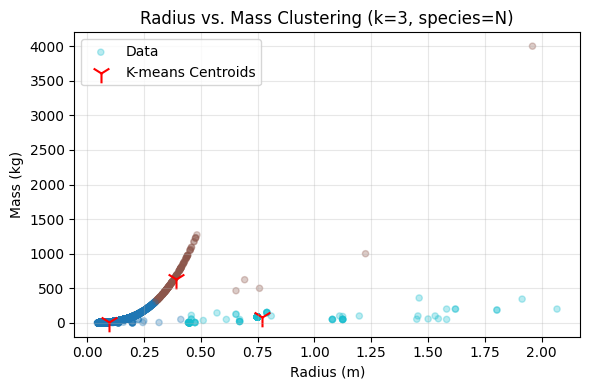

K-means centroid coordinates (radius (m), mass (kg)) for species N (k=3):
  Cluster 1: (0.09640, 18.47720)  n=13973
  Cluster 2: (0.39230, 630.64654)  n=171
  Cluster 3: (0.77129, 80.78545)  n=315
length of data for species N: 14459


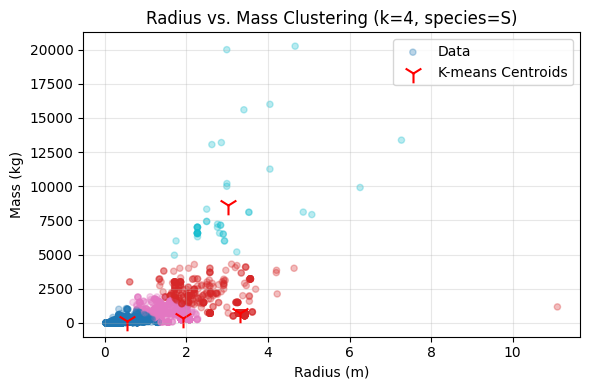

K-means centroid coordinates (radius (m), mass (kg)) for species S (k=4):
  Cluster 1: (0.54104, 126.10992)  n=3982
  Cluster 2: (3.31541, 741.91502)  n=5875
  Cluster 3: (1.92579, 385.66829)  n=4598
  Cluster 4: (3.02050, 8598.95818)  n=44
length of data for species S: 14499


In [24]:
# Cluster fit on K-means
species_names = list(Xs_by_species.keys())
k_list = [3, 3, 4]

for i, sp in enumerate(species_names):
    X = Xs_by_species[sp]
    k = k_list[i]
    group = cleaned_groups[sp]
    
    km = KMeans(n_clusters=k, random_state=0).fit(X)
    labels = km.labels_
    
    # unscale centers before plotting!
    scaler = StandardScaler().fit(group[['radius', 'mass']].dropna().values)
    centers_scaled = km.cluster_centers_
    centers_unscaled = scaler.inverse_transform(centers_scaled)
    
    if include_medoids and sp != "N":
        kmn = KMedoids(n_clusters=k, metric='manhattan', init='k-medoids++', random_state=0).fit(X)
        labels_medoids = kmn.labels_
        medoids = kmn.cluster_centers_
        medoids_unscaled = scaler.inverse_transform(medoids)

    
    df = group[['radius', 'mass']].dropna()
    
    plt.figure(figsize=(6, 4))
    plt.scatter(df['radius'], df['mass'], c=labels, cmap='tab10', s=20, alpha=0.3, label='Data')
    plt.scatter(centers_unscaled[:, 0], centers_unscaled[:, 1],
                marker='1', c='red', s=200, label='K-means Centroids')
    if include_medoids and sp != "N":
        plt.scatter(medoids_unscaled[:, 0], medoids_unscaled[:, 1],
                marker='2', c='blue', s=200, label='K-Medoids Medoids' if include_medoids else None)
    plt.xlabel('Radius (m)')
    plt.ylabel('Mass (kg)')
    plt.title(f'Radius vs. Mass Clustering (k={k}, species={sp})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    counts = np.bincount(labels, minlength=k)  # counts[j] = number of points in cluster j

    print(f"K-means centroid coordinates (radius (m), mass (kg)) for species {sp} (k={k}):")
    for j, center in enumerate(centers_unscaled):
        print(f"  Cluster {j+1}: ({center[0]:.5f}, {center[1]:.5f})  n={counts[j]}")
    
    print(f"length of data for species {sp}: {len(df)}")
     
    if include_medoids and sp != "N":
        print(f"K-Medoids centroid coordinates (radius (m), mass (kg)) for species {sp} (k={k}):")
        for j, medoid in enumerate(medoids_unscaled):
            print(f"  Medoid {j+1}: ({medoid[0]:.5f}, {medoid[1]:.5f})")
    

In [ ]:
# ### Species S (Active/Controlled)

# BASELINE
# K-means centroid coordinates (radius (m), mass (kg)) for species S (k=4):
#   Cluster 1: (1.42560, 814.76386)  n=36764
#   Cluster 2: (2.38697, 399.09054)  n=51860
#   Cluster 3: (16.22205, 1958.54274)  n=1604
#   Cluster 4: (13.53637, 7293.63927)  n=273
# length of data for species S: 90501
  
# "mass": [814.76386, 399.09054, 1958.54274, 7293.63927],
# "radius": [1.42560, 2.38697, 16.22205, 13.53637],

# BASELINE
# Cluster 1: (1.42559, 813.71347)  n=36758
#   Cluster 2: (2.39289, 399.70020)  n=51897
#   Cluster 3: (15.89561, 2779.91592)  n=1846

# "mass": [813.71347, 399.70020, 2779.91592],
# "radius": [1.42559, 2.39289, 15.89561],

# NFL
# K-means centroid coordinates (radius (m), mass (kg)) for species S (k=4):
#   Cluster 1: (0.54104, 126.10992)  n=3982
#   Cluster 2: (3.31541, 741.91502)  n=5875
#   Cluster 3: (1.92579, 385.66829)  n=4598
#   Cluster 4: (3.02050, 8598.95818)  n=44
# length of data for species S: 14499

# "mass": [126.10992, 741.91502, 385.66829, 8598.95818],
# "radius": [0.54104, 3.31541, 1.92579, 3.02050],


In [22]:
# "species": [
#         {
#         "sym_name": "S",
#         "Cd": 2.2,
#         "mass": [130, 385, 740, 8600],
#         "radius": [0.55, 1.92, 3.3, 3],
#         "A": "Calculated based on radius",
#         "active": true,
#         "maneuverable": true,
#         "trackable": true,
#         "deltat": 25,
#         "Pm": 0.90,
#         "alpha": 0,
#         "alpha_active": 0,
#         "slotted": true, 
#         "slotting_effectiveness": 1,
#         "drag_effected": false,
#         "launch_func": "launch_func_null",
#         "pmd_func": "pmd_func_sat",
#         "drag_func": "drag_func_exp"     
#       },
      
# {
#         "sym_name": "Sns",
#         "Cd": 2.2,
#         "mass": 5.7,
#         "radius": 0.15,
#         "A": "Calculated based on radius",
#         "active": true,
#         "maneuverable": false,
#         "deltat": 25,
#         "Pm": 0.90,
#         "alpha": 0,
#         "alpha_active": 0,
#         "slotted" : false, 
#         "slotting_effectiveness": 0,
#         "drag_effected": true,
#         "launch_func": "launch_func_null",
#         "pmd_func": "pmd_func_sat",
#         "drag_func": "drag_func_exp"
#       },

# {
#        "sym_name": "N",
#         "Cd": 2.2,
#         "mass": [2, 7.2, 72, 669, 88.5],
#         "radius": [0.02, 0.08, 0.18, 0.40, 0.80],
#         "A": "Calculated based on radius",
#         "active": false,
#         "maneuverable": false,
#         "trackable": false,
#         "deltat": null,
#         "Pm": 0,
#         "alpha": 0,
#         "alpha_active": 0,
#         "RBflag": 0,
#         "slotted": false,
#         "slotting_effectiveness": 0,
#         "drag_effected": true,
#         "launch_func": "launch_func_null",
#         "pmd_func": "pmd_func_derelict",
#         "drag_func": "drag_func_exp"
#     }

# {
#         "sym_name": "B",
#         "RBflag" : 1,
#         "Cd": 2.2,
#         "mass": [252, 1358, 5159],
#         "radius": [0.71, 1.91, 3.37],
#         "A": "Calculated based on radius",
#         "active": false,
#         "slotted": false,
#         "slotting_effectiveness": 0,
#         "drag_effected": true,
#         "deltat": 0,
#         "Pm": 0,
#         "alpha": 0,
#         "alpha_active": 0, 
#         "trackable": true,
#         "launch_func": "launch_func_null",
#         "pmd_func": "pmd_func_none",
#         "drag_func": "drag_func_exp"
#   }

#     "species_count": 17

In [23]:
# OTHER

# # Print the unique values in the 'species_class' column to verify the mapping
# unique_values = df['species_class'].unique()
# print(unique_values)
# unique_values1 = df1['object type'].unique()
# print(unique_values1)
# unique_values2 = df2['object type'].unique()
# print(unique_values2)

# # Print the full count for every object type in the dataframe
# print("--- Object Type Counts ---")
# print(df1['object type'].value_counts())

# # Print the count of 'Payload' objects and their status
# df1.loc[df1['object type'] == 'Payload', 'status [-]'].tolist()

# # Print the count of 'Payload' objects launched before 2020
# threshold_year = 2020
# old_objects = df1[df1['status [-]'] < threshold_year]
# print(f"--- Objects launched before {threshold_year} ---")
# print(old_objects['species_class'].value_counts())

# # Print the count of objects with sma < 6628000 m (LEO region)
# sma_objects = df1[df1['sma [m]'] < 6628000]
# print(sma_objects['object type'].value_counts())